# Diagnóstico de series temporales — Zona de contraste (Municipio A)

**Proyecto de Aprendizaje Automático (PAA) — UTEC / LIDIA 2026 · Predicción de siniestros viales**

Aplica a **Municipio A** el mismo análisis que
[`diagnostico_datos_municipio.ipynb`](diagnostico_datos_municipio.ipynb) hace sobre Municipio C:
la estructura temporal — tendencia, estacionalidad, autocorrelación (ACF/PACF) y dispersión por
rezago — de la serie diaria de siniestros de un único municipio, y la decisión, apoyada en esa
evidencia, de si corresponde diferenciar o transformar (logaritmo/Box-Cox) el objetivo antes de
modelarlo.

**Alcance: Municipio A, 2021-07-01 a 2025-12-31.** Municipio A es la zona de **contraste** que
reserva `preparacion_montevideo.ipynb`: ni la más activa (ese papel lo tiene Municipio C, 5.783
siniestros) ni la menos activa (Municipio CH, 3.377), sino la de **actividad mediana** entre los
ocho municipios (5.016 siniestros, **13,70 %** del total; `resumen_diagnostico_datos.md`, §4.2;
`resumen_preparacion_montevideo.md`, §7.5). El recorte territorial y temporal (Montevideo,
municipios, desde 2021-07-01) **se hereda tal cual** de `diagnostico_datos_municipio.ipynb` y,
más atrás, de `diagnostico_datos.ipynb`: esa decisión ya está justificada con evidencia en esos
dos notebooks y no se vuelve a discutir acá.

**Qué responde este notebook**

| Pregunta | Sección |
| --- | --- |
| ¿Hay tendencia, y estacionalidad diaria/semanal/anual, en la serie de Municipio A? | 2 |
| ¿Qué dice la ACF/PACF sobre la persistencia de la serie y su relación con el calendario? | 3 |
| ¿La dispersión entre un día y sus rezagos sugiere memoria del proceso? | 3.4 |
| ¿Corresponde diferenciar la serie o aplicar una transformación log/Box-Cox? | 4 |

**Qué NO hace.** No repite el diagnóstico de calidad, cobertura ni adecuación de
`diagnostico_datos.ipynb` — se remite a él. No decide el modelo final: alimenta esa decisión con
evidencia sobre la estructura temporal de una segunda serie de conteo bajo. **Tampoco reconstruye
la asignación punto-polígono**: a diferencia de `diagnostico_datos_municipio.ipynb` (que reimplementa
la asignación con `geopandas` sobre el CSV crudo como verificación cruzada independiente), este
notebook parte directamente de `data/processed/panel_zona_contraste.csv` — el panel de Municipio A
ya preparado y verificado por el ETL (`preparacion_montevideo.ipynb`, dieciséis comprobaciones en
OK, cruzado de forma independiente contra `diagnostico_datos.ipynb`; `resumen_preparacion_montevideo.md`,
§8). Repetir esa verificación espacial acá sería redundante; la sección 1 hace, en cambio, una
verificación cruzada numérica contra las cifras ya publicadas para Municipio A.

**Advertencia heredada del ETL, y que este notebook no contradice:** con la zonificación por
municipios, el par top/contraste **"ya casi no contrasta"** (razón 1,15×,
`resumen_preparacion_montevideo.md` §7.5, frente a 2,8× que medía con barrios). La comparación
Municipio C vs. Municipio A que puede leerse entre este notebook y `diagnostico_datos_municipio.ipynb`
**no debe presentarse como evidencia de generalización** — sólo da una segunda serie con
estructura temporal propia para contrastar.

**Fuentes.** Sólo `data/processed/panel_zona_contraste.csv` (ya incluye el clima; no hace falta
para este análisis, igual que en `diagnostico_datos_municipio.ipynb`).

**Artefactos.** Tablas y figuras en `experiments/diagnostico_zona_contraste/`.

## 0. Configuración y trazabilidad

In [1]:
import hashlib
import platform
import sys
from datetime import datetime, timezone
from pathlib import Path

import holidays
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats as sps
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, adfuller, kpss, pacf

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "processed").is_dir())
DIR_PROCESADO = RAIZ / "data" / "processed"
RUTA_CSV = DIR_PROCESADO / "panel_zona_contraste.csv"

DIR_SALIDA = RAIZ / "experiments" / "diagnostico_zona_contraste"
DIR_TABLAS = DIR_SALIDA / "tablas"
DIR_FIGURAS = DIR_SALIDA / "figuras"
for d in (DIR_TABLAS, DIR_FIGURAS):
    d.mkdir(parents=True, exist_ok=True)

# Alcance heredado de diagnostico_datos_municipio.ipynb y, más atrás, de diagnostico_datos.ipynb
# (secciones 2.6 y 3.1 de ese notebook). No se vuelve a justificar acá: panel_zona_contraste.csv
# ya viene recortado y verificado por preparacion_montevideo.ipynb (resumen_preparacion_montevideo.md, §8).
FECHA_INICIO = "2021-07-01"
MUNICIPIO_FOCO = "A"
CATEGORIAS_FERIADO = ("public", "bank")

pd.set_option("display.width", 130)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 140, "savefig.bbox": "tight",
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 9,
})


def guardar_tabla(tabla, nombre, indice=False):
    destino = DIR_TABLAS / f"{nombre}.csv"
    tabla.to_csv(destino, index=indice, encoding="utf-8")
    print(f"[tabla]  {destino.relative_to(RAIZ)}")
    display(tabla)


def guardar_figura(fig, nombre):
    destino = DIR_FIGURAS / f"{nombre}.png"
    fig.savefig(destino)
    print(f"[figura] {destino.relative_to(RAIZ)}")

A diferencia de `diagnostico_datos_municipio.ipynb`, acá no hace falta registrar la
procedencia del CSV crudo ni de la capa de municipios: `panel_zona_contraste.csv` ya es un
producto de `preparacion_montevideo.ipynb`, con su propia procedencia y sus dieciséis
verificaciones documentadas en `resumen_preparacion_montevideo.md` (§7–8). Lo que se registra acá
es la procedencia de ese archivo ya preparado.

In [2]:
FUENTES = [("panel_zona_contraste", RUTA_CSV)]
filas = []
for nombre, ruta in FUENTES:
    if not ruta.exists():
        filas.append((nombre, str(ruta.relative_to(RAIZ)), "AUSENTE", "", ""))
        continue
    filas.append((
        nombre, str(ruta.relative_to(RAIZ)), f"{ruta.stat().st_size / 1e6:.2f} MB",
        hashlib.sha256(ruta.read_bytes()).hexdigest(),
        datetime.fromtimestamp(ruta.stat().st_mtime).strftime("%Y-%m-%d %H:%M"),
    ))
procedencia = pd.DataFrame(filas, columns=["fuente", "archivo", "tamaño", "sha256", "modificado"])

paquetes = ["pandas", "numpy", "statsmodels", "scipy", "matplotlib", "holidays"]
import importlib.metadata as md_meta
entorno = pd.DataFrame(
    [("ejecutado", datetime.now(timezone.utc).astimezone().strftime("%Y-%m-%d %H:%M")),
     ("python", f"{sys.version.split()[0]} · {platform.system()} {platform.release()}"),
     ("municipio analizado", MUNICIPIO_FOCO)]
    + [(p, md_meta.version(p)) for p in paquetes], columns=["clave", "valor"])

guardar_tabla(procedencia, "00_procedencia")
guardar_tabla(entorno, "00b_entorno")

[tabla]  experiments\diagnostico_zona_contraste\tablas\00_procedencia.csv


,fuente,archivo,tamaño,sha256,modificado
0,panel_zona_contraste,data\processed\panel_zona_contraste.csv,0.12 MB,2cc99a39b3a554fea69606c4bef8ef6f4f76895d8d4989...,2026-09-07 14:30


[tabla]  experiments\diagnostico_zona_contraste\tablas\00b_entorno.csv


,clave,valor
0,ejecutado,2026-09-17 08:50
1,python,3.13.2 · Windows 10
2,municipio analizado,A
3,pandas,2.3.3
4,numpy,2.5.2
5,statsmodels,0.14.6
6,scipy,1.18.1
7,matplotlib,3.11.1
8,holidays,0.103


## 1. Carga del panel y verificación cruzada

### 1.1 Carga del panel ya preparado

A diferencia de `diagnostico_datos_municipio.ipynb` (que reconstruye la serie desde el CSV crudo
y la capa de municipios con `geopandas.sjoin`), acá no hace falta ninguna asignación
punto-polígono: `panel_zona_contraste.csv` ya trae una fila por (fecha, zona) para Municipio A,
producida y verificada por el ETL (`preparacion_montevideo.ipynb`, dieciséis comprobaciones en OK;
`resumen_preparacion_montevideo.md` §8). Lo que se hace acá es cargarlo y confirmar que tiene la
forma esperada: una sola zona, sin huecos de calendario ni fechas repetidas.

In [3]:
df = pd.read_csv(RUTA_CSV, encoding="utf-8")
df["fecha"] = pd.to_datetime(df["fecha"], format="%Y-%m-%d")

zonas_presentes = df["zona_id"].unique()
assert len(zonas_presentes) == 1, f"se esperaba una sola zona, hay {len(zonas_presentes)}"
assert zonas_presentes[0] == f"MUNICIPIO {MUNICIPIO_FOCO}", zonas_presentes[0]
assert df["fecha"].min() == pd.Timestamp(FECHA_INICIO), "la fecha de inicio no es la esperada"

FECHA_FIN = df["fecha"].max()
DIAS = pd.date_range(FECHA_INICIO, FECHA_FIN, freq="D")
faltantes_calendario = DIAS.difference(df["fecha"])
duplicados_fecha = int(df["fecha"].duplicated().sum())

carga = pd.DataFrame(
    [("filas del panel", len(df)),
     ("zona presente", zonas_presentes[0]),
     ("fecha mínima", df["fecha"].min().strftime("%Y-%m-%d")),
     ("fecha máxima", df["fecha"].max().strftime("%Y-%m-%d")),
     ("huecos de calendario", len(faltantes_calendario)),
     ("fechas duplicadas", duplicados_fecha)],
    columns=["indicador", "valor"],
)
guardar_tabla(carga, "01_carga_panel")

print(f"período: {DIAS[0]:%Y-%m-%d} -> {DIAS[-1]:%Y-%m-%d}  ({len(DIAS):,} días)")
assert len(faltantes_calendario) == 0, "el panel tiene huecos de calendario"
assert duplicados_fecha == 0, "hay fechas repetidas en el panel" 

[tabla]  experiments\diagnostico_zona_contraste\tablas\01_carga_panel.csv


,indicador,valor
0,filas del panel,1645
1,zona presente,MUNICIPIO A
2,fecha mínima,2021-07-01
3,fecha máxima,2025-12-31
4,huecos de calendario,0
5,fechas duplicadas,0


período: 2021-07-01 -> 2025-12-31  (1,645 días)


### 1.2 Verificación cruzada con el diagnóstico principal

El total de siniestros y el porcentaje de días en cero de Municipio A ya están citados en
`resumen_diagnostico_datos.md` (§4.2) y en `resumen_preparacion_montevideo.md` (§7.5, tabla
`09_zonas_seleccionadas.csv`), calculados con implementaciones distintas (polígonos manuales y el
ETL). Si el panel ya preparado reproduce esas cifras, es una **tercera** confirmación
independiente — la misma lógica de verificación cruzada que usan los otros dos notebooks.

In [4]:
REFERENCIA_MUNICIPIOS = {
    "C": 5783, "B": 5377, "D": 5319, "A": 5016,
    "F": 4424, "G": 3701, "E": 3615, "CH": 3377,
}
# resumen_preparacion_montevideo.md, tabla `09_zonas_seleccionadas.csv` (§7.5)
REFERENCIA_ZONAS_SELECCIONADAS = {
    "C": {"papel": "más activo", "siniestros": 5783, "pct_dias_cero": 4.80},
    "A": {"papel": "contraste (actividad mediana)", "siniestros": 5016, "pct_dias_cero": 5.84},
}

total_calculado = int(df["n_siniestros"].sum())
pct_ceros_calculado = round(100 * (df["n_siniestros"] == 0).mean(), 2)

comparacion = pd.DataFrame([
    ("siniestros totales", REFERENCIA_MUNICIPIOS[MUNICIPIO_FOCO], total_calculado,
     "coincide" if REFERENCIA_MUNICIPIOS[MUNICIPIO_FOCO] == total_calculado else "DIFIERE"),
    ("% de días en cero", REFERENCIA_ZONAS_SELECCIONADAS[MUNICIPIO_FOCO]["pct_dias_cero"], pct_ceros_calculado,
     "coincide" if REFERENCIA_ZONAS_SELECCIONADAS[MUNICIPIO_FOCO]["pct_dias_cero"] == pct_ceros_calculado else "DIFIERE"),
], columns=["indicador", "referencia (resumen_diagnostico_datos.md / resumen_preparacion_montevideo.md)",
            "recalculado sobre panel_zona_contraste.csv", "resultado"])
guardar_tabla(comparacion, "02_verificacion_cruzada")
assert (comparacion["resultado"] == "coincide").all(), "el panel ya preparado no coincide con las referencias externas"
print("El total y el % de días en cero coinciden con resumen_diagnostico_datos.md y resumen_preparacion_montevideo.md.")

[tabla]  experiments\diagnostico_zona_contraste\tablas\02_verificacion_cruzada.csv


,indicador,referencia (resumen_diagnostico_datos.md / resumen_preparacion_montevideo.md),recalculado sobre panel_zona_contraste.csv,resultado
0,siniestros totales,5016.00,5016.00,coincide
1,% de días en cero,5.84,5.84,coincide


El total y el % de días en cero coinciden con resumen_diagnostico_datos.md y resumen_preparacion_montevideo.md.


### 1.3 La serie diaria de Municipio A

Se indexa por fecha contra el calendario completo del período (`DIAS`); la sección 1.1 ya confirmó
que no hay huecos, así que el `reindex` es defensivo, no correctivo.

In [5]:
serie_a = df.set_index("fecha")["n_siniestros"].reindex(DIAS, fill_value=0).rename("n_siniestros")
serie_a.index.name = "fecha"

media, varianza = serie_a.mean(), serie_a.var(ddof=0)
resumen_serie = pd.DataFrame(
    [("municipio", MUNICIPIO_FOCO),
     ("días del período", len(DIAS)),
     ("siniestros totales", int(serie_a.sum())),
     ("días en cero", int((serie_a == 0).sum())),
     ("% de días en cero", round(100 * (serie_a == 0).mean(), 2)),
     ("media diaria", round(media, 4)),
     ("varianza diaria (ddof=0)", round(varianza, 4)),
     ("índice de dispersión (var/media)", round(varianza / media, 4)),
     ("máximo diario", int(serie_a.max())),
     ("mediana diaria", float(serie_a.median()))],
    columns=["indicador", "valor"],
)
guardar_tabla(resumen_serie, "03_resumen_serie_municipio_a")

[tabla]  experiments\diagnostico_zona_contraste\tablas\03_resumen_serie_municipio_a.csv


,indicador,valor
0,municipio,A
1,días del período,1645
2,siniestros totales,5016
3,días en cero,96
4,% de días en cero,5.84
5,media diaria,3.0492
6,varianza diaria (ddof=0),3.4231
7,índice de dispersión (var/media),1.1226
8,máximo diario,11
9,mediana diaria,3.0


**Evidencia:** Municipio A tiene una dispersión (var/media = 1,1226) más leve que Municipio C
(var/media ≈ 1,26; `diagnostico_datos_municipio.ipynb`, tabla `04_resumen_serie_municipio_c.csv`):
la serie de A está más cerca de un proceso Poisson puro (var = media) que la de C. Con 96 días en
cero (5,84 %) y media diaria de 3,05 siniestros, Municipio A tiene algo menos de soporte que
Municipio C (4,80 % de días en cero, media ≈3,5/día), pero sigue siendo suficiente para los
análisis exploratorios de la sección siguiente.

## 2. Gráficos exploratorios: tendencia y estacionalidad

### 2.1 Tendencia

Serie diaria cruda con medias móviles de 30 y 90 días, y la media anual (el 2021 sólo aporta
julio-diciembre, igual que en el resto del diagnóstico).

[figura] experiments\diagnostico_zona_contraste\figuras\fig1_tendencia_municipio_a.png


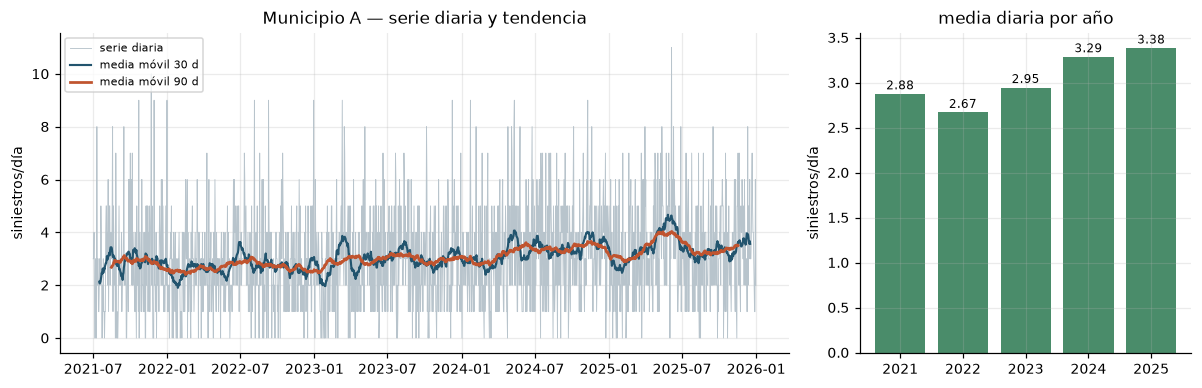

[tabla]  experiments\diagnostico_zona_contraste\tablas\04_tendencia_anual.csv


,año,media_diaria
0,2021,2.8750
1,2022,2.6685
2,2023,2.9452
3,2024,3.2869
4,2025,3.3836


In [6]:
media_movil_30 = serie_a.rolling(30, center=True).mean()
media_movil_90 = serie_a.rolling(90, center=True).mean()
media_anual = serie_a.groupby(serie_a.index.year).mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [2.2, 1]})

ax1.plot(serie_a.index, serie_a.values, color="#b8c4cc", lw=0.6, label="serie diaria")
ax1.plot(media_movil_30.index, media_movil_30.values, color="#22546e", lw=1.4, label="media móvil 30 d")
ax1.plot(media_movil_90.index, media_movil_90.values, color="#c0542f", lw=1.8, label="media móvil 90 d")
ax1.set_title(f"Municipio {MUNICIPIO_FOCO} — serie diaria y tendencia")
ax1.set_ylabel("siniestros/día"); ax1.legend(fontsize=7, loc="upper left")

ax2.bar(media_anual.index.astype(str), media_anual.values, color="#4a8c6a")
for x, v in zip(media_anual.index.astype(str), media_anual.values):
    ax2.text(x, v + 0.05, f"{v:.2f}", ha="center", fontsize=8)
ax2.set_title("media diaria por año")
ax2.set_ylabel("siniestros/día")

fig.tight_layout()
guardar_figura(fig, "fig1_tendencia_municipio_a")
plt.show()

guardar_tabla(
    media_anual.rename("media_diaria").round(4).reset_index().rename(columns={"fecha": "año"}),
    "04_tendencia_anual",
)

**Evidencia:** a diferencia de Municipio C (que baja de 2021 a 2023 y recién sube en 2024-2025), la
media anual de Municipio A **cae sólo el primer año** (2021→2022: 2,88→2,67 siniestros/día) y
luego **sube cada año** hasta 2025 (2,67→2,95→3,29→3,38), un crecimiento de **+17,7 %** entre el
mínimo (2022) y el máximo (2025) del período. Es un patrón más parecido al crecimiento sostenido
que reporta el agregado departamental (`resumen_diagnostico_datos.md` §4.1: 21,4 → 24,6
siniestros/día entre 2021 y 2025, +14,95 %) que al de Municipio C, que no es monótono.

**Inferencia del equipo:** el crecimiento agregado del departamento no se reparte igual entre
municipios, pero tampoco es exclusivo de uno solo: Municipio A también crece, y de forma más
parecida al agregado que Municipio C. Con sólo dos series no alcanza para generalizar el patrón a
los seis municipios restantes.

### 2.2 Estacionalidad diaria/semanal

Perfil por día de la semana (media de siniestros).

[tabla]  experiments\diagnostico_zona_contraste\tablas\05_perfil_semanal.csv


,fecha,media_siniestros_dia
0,lunes,3.0298
1,martes,3.1064
2,miércoles,3.0170
3,jueves,2.8894
4,viernes,3.5234
5,sábado,3.3106
6,domingo,2.4681


[figura] experiments\diagnostico_zona_contraste\figuras\fig2a_perfil_semanal_municipio_a.png


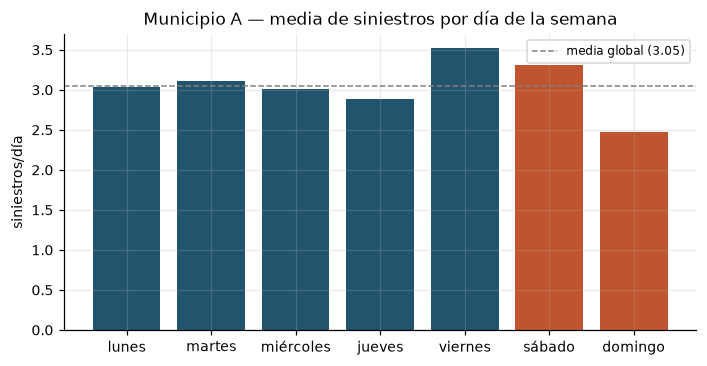

razón viernes/domingo: 1.43x


In [7]:
DIAS_SEMANA_ES = {0: "lunes", 1: "martes", 2: "miércoles", 3: "jueves",
                   4: "viernes", 5: "sábado", 6: "domingo"}
orden_semana = [DIAS_SEMANA_ES[i] for i in range(7)]

perfil_semanal = serie_a.groupby(serie_a.index.dayofweek.map(DIAS_SEMANA_ES)).mean().reindex(orden_semana)
perfil_semanal_tab = perfil_semanal.round(4).rename("media_siniestros_dia").reset_index().rename(columns={"index": "día"})
guardar_tabla(perfil_semanal_tab, "05_perfil_semanal")

fig, ax = plt.subplots(figsize=(6.5, 3.4))
colores = ["#22546e"] * 5 + ["#c0542f", "#c0542f"]
ax.bar(orden_semana, perfil_semanal.values, color=colores)
ax.axhline(serie_a.mean(), color="grey", ls="--", lw=1, label=f"media global ({serie_a.mean():.2f})")
ax.set_title(f"Municipio {MUNICIPIO_FOCO} — media de siniestros por día de la semana")
ax.set_ylabel("siniestros/día"); ax.legend(fontsize=8)
fig.tight_layout()
guardar_figura(fig, "fig2a_perfil_semanal_municipio_a")
plt.show()

print(f"razón viernes/domingo: {perfil_semanal['viernes'] / perfil_semanal['domingo']:.2f}x")

**Evidencia:** el orden semanal de Municipio A también tiene **viernes** como máximo (3,52) y
**domingo** como mínimo (2,47), igual que el agregado departamental (`resumen_diagnostico_datos.md`
§4.4: viernes 25,74, domingo 16,06 sobre las ocho zonas, razón ≈1,60×) y que Municipio C. La razón
viernes/domingo de Municipio A (**1,43×**) es, sin embargo, **menos marcada** que la del agregado
departamental y que la de Municipio C (donde, según `diagnostico_datos_municipio.ipynb` §2.2, la
razón es más marcada que el agregado): el patrón semanal está presente en las dos zonas, pero no
con la misma intensidad.

### 2.3 Estacionalidad anual

Índice estacional mensual (cada mes dividido por la media de *su propio año*) y la descomposición
clásica (`statsmodels.tsa.seasonal.seasonal_decompose`, aditiva) de la serie diaria con período
365.

[tabla]  experiments\diagnostico_zona_contraste\tablas\06_indice_estacional_mensual.csv


,mes,índice_estacional
0,1,0.7967
1,2,0.8760
2,3,1.0221
3,4,0.9633
4,5,1.0833
5,6,1.0613
6,7,0.9776
7,8,1.0576
8,9,0.9864
9,10,1.0158


[figura] experiments\diagnostico_zona_contraste\figuras\fig2b_estacionalidad_anual_municipio_a.png


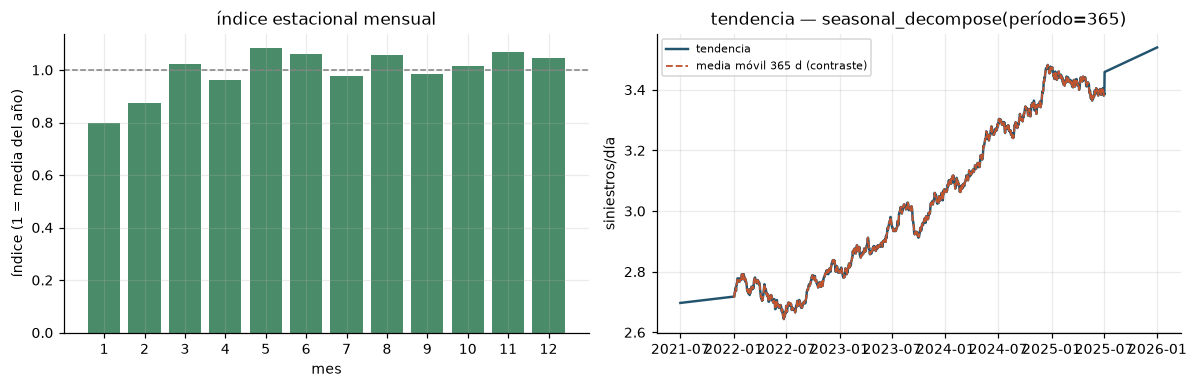

mes más bajo: 1 (índice 0.797) · mes más alto: 5 (índice 1.083)


In [8]:
tmp = serie_a.to_frame("n")
tmp["año"], tmp["mes"] = tmp.index.year, tmp.index.month
indice_mensual = (tmp["n"] / tmp.groupby("año")["n"].transform("mean")).groupby(tmp["mes"]).mean()
guardar_tabla(indice_mensual.round(4).rename("índice_estacional").reset_index(), "06_indice_estacional_mensual")

descomp = seasonal_decompose(serie_a, model="additive", period=365, extrapolate_trend="freq")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
ax1.bar(indice_mensual.index, indice_mensual.values, color="#4a8c6a")
ax1.axhline(1.0, color="grey", ls="--", lw=1)
ax1.set_xticks(range(1, 13)); ax1.set_xlabel("mes"); ax1.set_ylabel("índice (1 = media del año)")
ax1.set_title("índice estacional mensual")

ax2.plot(descomp.trend.index, descomp.trend.values, color="#22546e", lw=1.6, label="tendencia")
ax2.plot(serie_a.index, serie_a.rolling(365, center=True).mean(), color="#c0542f", lw=1.2,
         ls="--", label="media móvil 365 d (contraste)")
ax2.set_title("tendencia — seasonal_decompose(período=365)")
ax2.set_ylabel("siniestros/día"); ax2.legend(fontsize=7)

fig.tight_layout()
guardar_figura(fig, "fig2b_estacionalidad_anual_municipio_a")
plt.show()

print(f"mes más bajo: {indice_mensual.idxmin()} (índice {indice_mensual.min():.3f}) · "
      f"mes más alto: {indice_mensual.idxmax()} (índice {indice_mensual.max():.3f})")

**Evidencia:** el índice estacional de Municipio A tiene su mínimo en **enero** (0,797), igual que
Municipio C, pero su máximo está en **mayo** (1,083) y no en junio (que en Municipio A es el
segundo más alto, 1,061) — el mes de mayor actividad no coincide exactamente entre las dos zonas,
aunque ambas comparten el mínimo de enero y evitan el patrón «verano = más siniestros».

**Frase que estos datos NO sostienen:** «el verano tiene más siniestros por las vacaciones» —
enero (0,797) y febrero (0,876) son, de los doce meses, los dos de índice más bajo, igual que en
Municipio C.

## 3. Autocorrelación (ACF/PACF) y dispersión por rezago

Igual que en `diagnostico_datos_municipio.ipynb`, se usa la banda analítica de ±1,96/√n
del ACF/PACF estándar de `statsmodels` — razonable para una serie de conteo moderado, lejos de
cero (media ≈3,05/día, sección 1.3) — y la sección 4 confirma con ADF si la serie es estacionaria
en media, condición bajo la que esa banda es válida. Se calcula sobre la serie cruda y, después,
sobre el residuo de descontar el día de la semana y el feriado.

[figura] experiments\diagnostico_zona_contraste\figuras\fig3a_acf_pacf_crudo_municipio_a.png


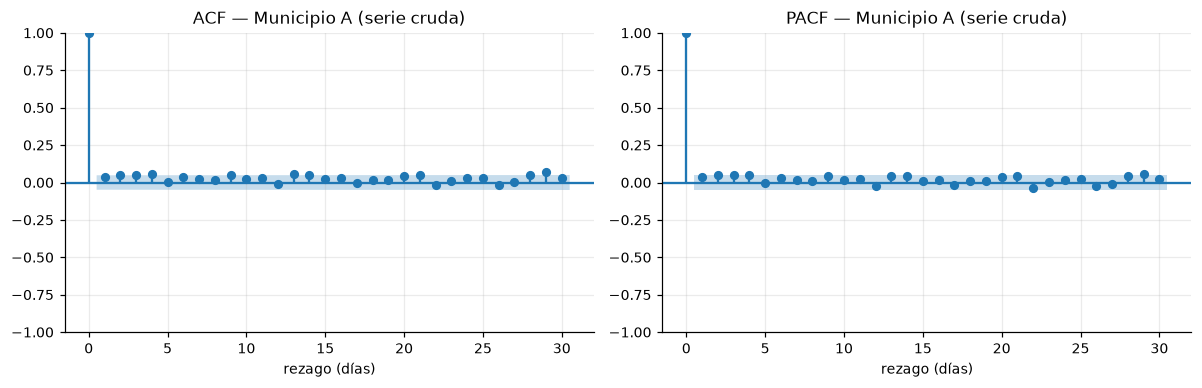

[tabla]  experiments\diagnostico_zona_contraste\tablas\07_acf_pacf_crudo.csv


,rezago,acf,pacf,fuera_de_banda_95
0,0,1.0000,NaN,True
1,1,0.0396,0.0396,False
2,2,0.0487,0.0472,True
3,3,0.0526,0.0491,True
4,4,0.0550,0.0495,True
5,5,0.0031,-0.0053,False
6,6,0.0351,0.0282,False
7,7,0.0266,0.0196,False
8,8,0.0168,0.0101,False
9,9,0.0470,0.0419,False


banda 95%: ±0.0483


In [9]:
NLAGS = 30
banda_95 = 1.96 / np.sqrt(len(serie_a))
vals = serie_a.to_numpy(float)

acf_cruda = acf(vals, nlags=NLAGS, fft=True)
pacf_cruda = pacf(vals, nlags=NLAGS)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
plot_acf(vals, lags=NLAGS, ax=axes[0], title=f"ACF — Municipio {MUNICIPIO_FOCO} (serie cruda)")
plot_pacf(vals, lags=NLAGS, ax=axes[1], method="ywm",
          title=f"PACF — Municipio {MUNICIPIO_FOCO} (serie cruda)")
for ax in axes:
    ax.set_xlabel("rezago (días)")
fig.tight_layout()
guardar_figura(fig, "fig3a_acf_pacf_crudo_municipio_a")
plt.show()

tabla_acf = pd.DataFrame({
    "rezago": range(NLAGS + 1), "acf": acf_cruda.round(4), "pacf": np.r_[np.nan, pacf_cruda[1:]].round(4),
})
tabla_acf["fuera_de_banda_95"] = tabla_acf["acf"].abs() > banda_95
guardar_tabla(tabla_acf, "07_acf_pacf_crudo")
print(f"banda 95%: ±{banda_95:.4f}")

### 3.1 Cuánto de la ACF cruda es calendario

Se resta a cada día la media de su grupo (día de la semana, con el feriado como grupo aparte) y se
recalcula la ACF sobre ese residuo.

[figura] experiments\diagnostico_zona_contraste\figuras\fig3b_acf_residuo_calendario_municipio_a.png


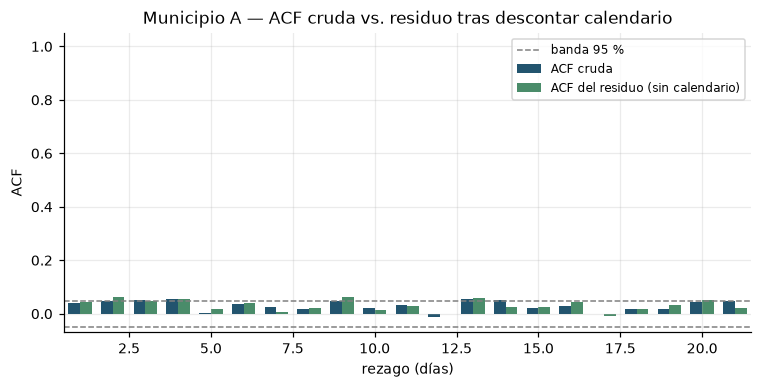

[tabla]  experiments\diagnostico_zona_contraste\tablas\08_acf_residuo_calendario.csv


,rezago,acf_cruda,acf_residuo,fuera_banda_cruda,fuera_banda_residuo
0,0,1.0000,1.0000,True,True
1,1,0.0396,0.0450,False,False
2,2,0.0487,0.0642,True,True
3,3,0.0526,0.0472,True,False
4,4,0.0550,0.0549,True,True
5,5,0.0031,0.0195,False,False
6,6,0.0351,0.0420,False,False
7,7,0.0266,0.0064,False,False
8,8,0.0168,0.0228,False,False
9,9,0.0470,0.0640,False,True


[tabla]  experiments\diagnostico_zona_contraste\tablas\09_ljung_box.csv


,rezago_max,lb_stat,lb_pvalue
0,7,19.271056,0.007379
1,14,35.291242,0.001331
2,30,64.481366,0.000255


In [10]:
fer = holidays.country_holidays("UY", years=range(DIAS[0].year, DIAS[-1].year + 1),
                                 categories=CATEGORIAS_FERIADO)
es_feriado = pd.Series(DIAS.date, index=DIAS).map(lambda d: d in fer)
grupo_cal = pd.Series(np.where(es_feriado, "feriado", DIAS.dayofweek.map(DIAS_SEMANA_ES)), index=DIAS)

medias_grupo = serie_a.groupby(grupo_cal).transform("mean")
residuo_cal = (serie_a - medias_grupo).to_numpy(float)
acf_residuo = acf(residuo_cal, nlags=NLAGS, fft=True)

fig, ax = plt.subplots(figsize=(7, 3.6))
x = np.arange(NLAGS + 1)
ax.bar(x - 0.18, acf_cruda, width=0.36, color="#22546e", label="ACF cruda")
ax.bar(x + 0.18, acf_residuo, width=0.36, color="#4a8c6a", label="ACF del residuo (sin calendario)")
ax.axhline(banda_95, color="grey", ls="--", lw=1)
ax.axhline(-banda_95, color="grey", ls="--", lw=1, label="banda 95 %")
ax.set_xlim(0.5, 21.5); ax.set_xlabel("rezago (días)"); ax.set_ylabel("ACF")
ax.set_title(f"Municipio {MUNICIPIO_FOCO} — ACF cruda vs. residuo tras descontar calendario")
ax.legend(fontsize=8)
fig.tight_layout()
guardar_figura(fig, "fig3b_acf_residuo_calendario_municipio_a")
plt.show()

tabla_residuo = pd.DataFrame({"rezago": range(NLAGS + 1), "acf_cruda": acf_cruda.round(4),
                               "acf_residuo": acf_residuo.round(4)})
tabla_residuo["fuera_banda_cruda"] = tabla_residuo["acf_cruda"].abs() > banda_95
tabla_residuo["fuera_banda_residuo"] = tabla_residuo["acf_residuo"].abs() > banda_95
guardar_tabla(tabla_residuo, "08_acf_residuo_calendario")

lb = acorr_ljungbox(vals, lags=[7, 14, 30], return_df=True).reset_index(names="rezago_max")
guardar_tabla(lb.round(6), "09_ljung_box")

**Evidencia:**

- En la ACF **cruda**, los rezagos fuera de la banda del 95 % (±0,0483) son 2, 3, 4, 13, 14, 28 y
  29 — a diferencia de Municipio C, **no** es la firma clásica de un ciclo semanal (múltiplos de
  7): el rezago 7 (0,0266) y el 21 (0,0475) quedan **dentro** de la banda, y el 1 también (0,0396).
- Al descontar el día de la semana y el feriado, el conjunto de rezagos fuera de banda **cambia**
  en vez de reducirse de forma sistemática: 3, 14 y 28 pasan a estar dentro de banda, pero 9 y 20
  pasan a estar fuera. El calendario no explica un patrón tan claro como en Municipio C — la
  autocorrelación de Municipio A parece más difusa que estructurada por semana.
- El test de Ljung-Box rechaza «no autocorrelación conjunta» con `p < 0,05` en los tres horizontes
  probados (7, 14 y 30 rezagos: `p` = 0,0074; 0,0013; 0,00026), aunque con menos margen que en
  Municipio C (`p < 0,001` en los tres). Hay estructura temporal estadísticamente detectable, pero
  más débil y menos concentrada en el calendario semanal que en la zona más activa.

**Inferencia del equipo:** en Municipio A el calendario semanal pesa menos como explicación de la
autocorrelación que en Municipio C — coherente con la razón viernes/domingo más chica de la
sección 2.2. Lo que queda tras descontar calendario no tiene un patrón fácil de nombrar (los
rezagos 9 y 20 no tienen una interpretación de calendario obvia) y se deja señalado, no explicado.

### 3.4 Dispersión por rezago (*scatter* de rezago)

Cada punto es un par (siniestros del día *t*, siniestros del día *t−k*), para k = 1, 7, 14 y 30.

[figura] experiments\diagnostico_zona_contraste\figuras\fig4_dispersion_lags_municipio_a.png


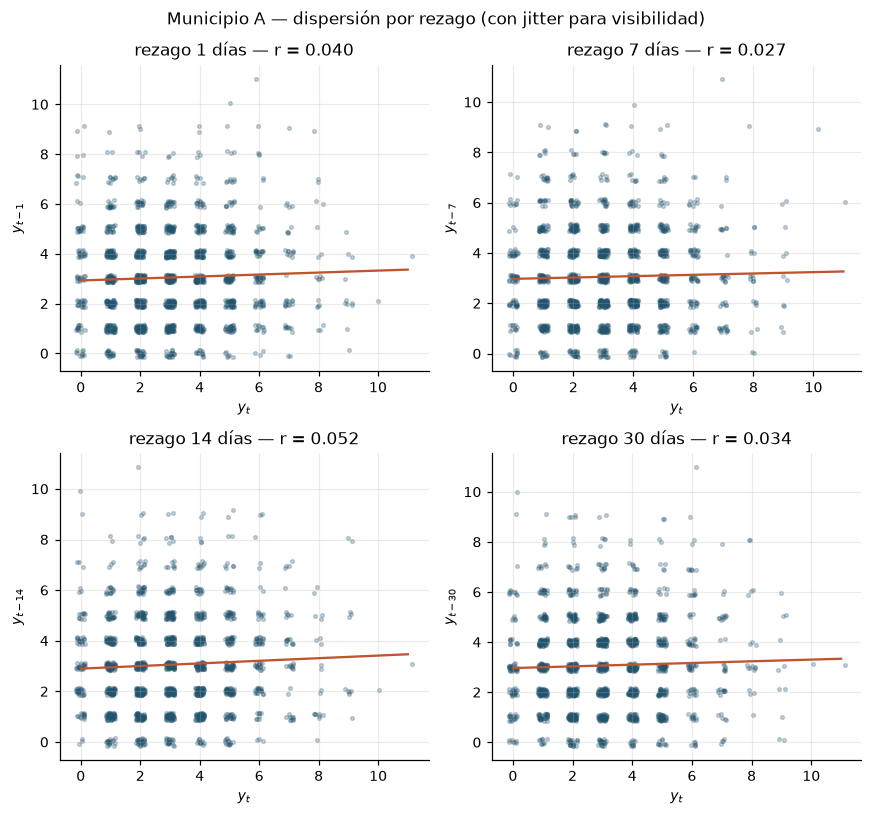

[tabla]  experiments\diagnostico_zona_contraste\tablas\10_dispersion_por_rezago.csv


,rezago,correlación_pearson
0,1,0.0396
1,7,0.0267
2,14,0.0517
3,30,0.0338


In [11]:
rezagos_scatter = [1, 7, 14, 30]
fig, axes = plt.subplots(2, 2, figsize=(8, 7.5))
filas_corr = []
rng = np.random.default_rng(42)
for ax, k in zip(axes.ravel(), rezagos_scatter):
    x, y = vals[:-k], vals[k:]
    jitter_x = x + rng.uniform(-0.15, 0.15, size=len(x))
    jitter_y = y + rng.uniform(-0.15, 0.15, size=len(y))
    r = np.corrcoef(x, y)[0, 1]
    filas_corr.append((k, round(r, 4)))
    ax.scatter(jitter_x, jitter_y, s=6, alpha=0.25, color="#22546e")
    m, b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, m * xs + b, color="#c0542f", lw=1.5)
    ax.set_title(f"rezago {k} días — r = {r:.3f}")
    ax.set_xlabel(f"$y_t$"); ax.set_ylabel(f"$y_{{t-{k}}}$")
fig.suptitle(f"Municipio {MUNICIPIO_FOCO} — dispersión por rezago (con jitter para visibilidad)")
fig.tight_layout()
guardar_figura(fig, "fig4_dispersion_lags_municipio_a")
plt.show()

guardar_tabla(pd.DataFrame(filas_corr, columns=["rezago", "correlación_pearson"]), "10_dispersion_por_rezago")

**Evidencia:** las correlaciones son todas chicas (r ≤ 0,052 en los cuatro rezagos) y, a diferencia
de lo esperable si hubiera memoria de corto plazo, **no decaen con el rezago**: el coeficiente más
alto es el del rezago 14 (r=0,0517), no el del rezago 1 (r=0,0396). Es consistente con la lectura
de la sección 3.1: la señal es pequeña y no tiene una estructura de calendario o de memoria simple
que la organice.

## 4. ¿Corresponde diferenciar o transformar el objetivo?

La pregunta tiene dos partes: **(a)** ¿hay una tendencia/raíz unitaria que justifique diferenciar
en nivel?, y **(b)** ¿la varianza escala con el nivel de forma que justifique estabilizarla con
logaritmo o Box-Cox? Se responden con evidencia, no por convención de manual de series temporales
— la serie es un conteo bajo con ceros (5,84 % de los días).

### 4.1 Estacionariedad: ADF y KPSS

In [12]:
adf_stat, adf_p, *_ = adfuller(vals, autolag="AIC")
kpss_stat, kpss_p, *_ = kpss(vals, regression="c", nlags="auto")

estacionariedad = pd.DataFrame(
    [("ADF", "H0: hay raíz unitaria (no estacionaria)", round(adf_stat, 4), f"{adf_p:.2e}",
      "rechaza H0 (estacionaria)" if adf_p < 0.05 else "no rechaza H0"),
     ("KPSS", "H0: la serie es estacionaria", round(kpss_stat, 4),
      f"≤ 0.01" if kpss_p <= 0.01 else f"{kpss_p:.4f}",
      "rechaza H0 (no estacionaria)" if kpss_p < 0.05 else "no rechaza H0")],
    columns=["prueba", "hipótesis nula", "estadístico", "p-valor", "resultado (α=0,05)"],
)
guardar_tabla(estacionariedad, "11_estacionariedad_adf_kpss")

[tabla]  experiments\diagnostico_zona_contraste\tablas\11_estacionariedad_adf_kpss.csv


C:\Users\victo\AppData\Local\Temp\ipykernel_2436\384581073.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(vals, regression="c", nlags="auto")


,prueba,hipótesis nula,estadístico,p-valor,"resultado (α=0,05)"
0,ADF,H0: hay raíz unitaria (no estacionaria),-17.8908,2.98e-30,rechaza H0 (estacionaria)
1,KPSS,H0: la serie es estacionaria,2.8405,≤ 0.01,rechaza H0 (no estacionaria)


**Evidencia — la misma tensión que en Municipio C, con margen aún mayor:** el ADF rechaza la raíz
unitaria con margen incluso mayor que en Municipio C (`p` del orden de 10⁻³⁰, contra 10⁻¹⁰ en C):
sobre esta prueba, estacionaria en media. El KPSS también rechaza la estacionariedad (`p ≤ 0,01`,
y el aviso de `statsmodels` indica que el p-valor real es todavía menor que ese límite tabulado).

**Lectura del equipo:** igual que en Municipio C, la combinación es compatible con una serie
estacionaria alrededor de un nivel que deriva despacio (acá: cae en 2022 y sube sostenidamente
2022-2025, sección 2.1), no con una tendencia determinística fuerte ni con una caminata aleatoria.
Que el mismo patrón — ADF estacionario, KPSS no — aparezca en dos municipios distintos es evidencia
a favor de que es una propiedad genuina del proceso (nivel que deriva lentamente) y no un artefacto
de una sola serie.

### 4.2 ¿Diferenciar ayuda o sobrecorrige?

In [13]:
diff1 = np.diff(vals, n=1)
diff7 = vals[7:] - vals[:-7]

comparacion_diff = pd.DataFrame({
    "serie": ["cruda", "diferenciada (d=1)", "diferenciada estacional (D=1, s=7)"],
    "acf_rezago_1": [round(acf(s, nlags=1, fft=True)[1], 4) for s in (vals, diff1, diff7)],
    "acf_rezago_2": [round(acf(s, nlags=2, fft=True)[2], 4) for s in (vals, diff1, diff7)],
    "acf_rezago_7": [round(acf(s, nlags=7, fft=True)[7], 4) for s in (vals, diff1, diff7)],
    "varianza": [round(np.var(s), 4) for s in (vals, diff1, diff7)],
})
guardar_tabla(comparacion_diff, "12_efecto_diferenciacion")

[tabla]  experiments\diagnostico_zona_contraste\tablas\12_efecto_diferenciacion.csv


,serie,acf_rezago_1,acf_rezago_2,acf_rezago_7,varianza
0,cruda,0.0396,0.0487,0.0266,3.4231
1,diferenciada (d=1),-0.5044,0.0022,0.0006,6.5785
2,"diferenciada estacional (D=1, s=7)",0.0131,0.0241,-0.5104,6.6679


**Evidencia:** igual que en Municipio C, diferenciar en nivel (d=1) **no reduce** la
autocorrelación: la vuelve fuertemente **negativa** en el rezago 1 (-0,5044, incluso más marcada
que en Municipio C, ≈-0,46) y **casi duplica la varianza** (3,42 → 6,58) — sobrediferenciación
clara. La diferenciación estacional (s=7) tiene el mismo problema en su propio rezago
(acf_rezago_7 = -0,5104) y también casi duplica la varianza (6,67). **Ninguna de las dos ayuda.**

**Inferencia del equipo:** consistente con el ADF de 4.1 — sin raíz unitaria, diferenciar no
resuelve un problema real y sí introduce uno (sobrediferenciación), igual que en Municipio C.

### 4.3 ¿La varianza escala con el nivel? Log, Box-Cox y la alternativa de conteo

[figura] experiments\diagnostico_zona_contraste\figuras\fig5_transformaciones_municipio_a.png


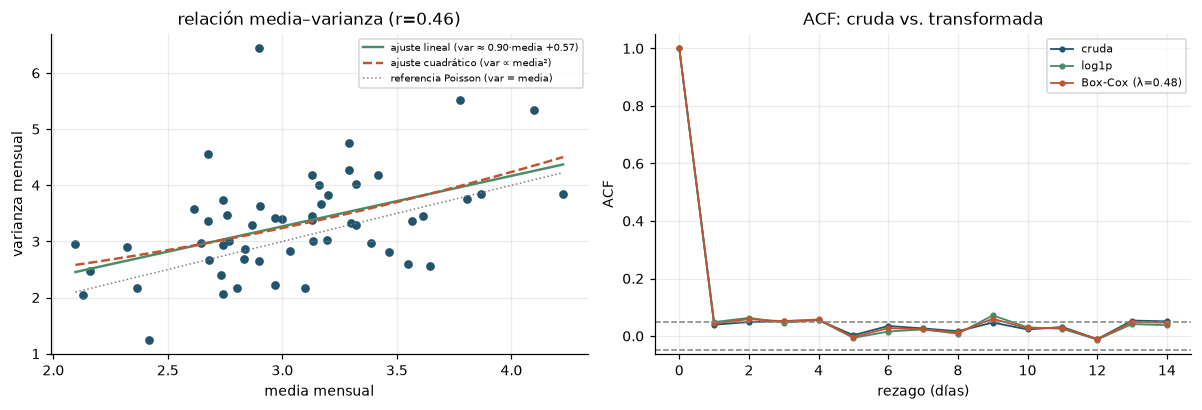

[tabla]  experiments\diagnostico_zona_contraste\tablas\13_diagnostico_transformacion.csv


,indicador,valor
0,"ajuste lineal var~media (pendiente, intercepto)","0.900, 0.568"
1,"ajuste cuadrático var~media² (pendiente, inter...","0.143, 1.955"
2,correlación media–varianza mensual,0.4597
3,λ de Box-Cox estimado por máxima verosimilitud...,0.475
4,λ=0 equivaldría a,logaritmo
5,"λ=0,5 equivaldría a",raíz cuadrada (transformación de Anscombe para...
6,λ=1 equivaldría a,sin transformar


In [14]:
tmp = serie_a.to_frame("n")
tmp["mes"] = tmp.index.to_period("M")
por_mes = tmp.groupby("mes")["n"].agg(["mean", "var"]).rename(columns={"mean": "media", "var": "varianza"})

coef_lineal = np.polyfit(por_mes["media"], por_mes["varianza"], 1)
coef_cuadratico = np.polyfit(por_mes["media"] ** 2, por_mes["varianza"], 1)
r_lineal = np.corrcoef(por_mes["media"], por_mes["varianza"])[0, 1]

lam_boxcox = sps.boxcox_normmax(vals + 1, method="mle")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))

ax1.scatter(por_mes["media"], por_mes["varianza"], s=22, color="#22546e")
xs = np.linspace(por_mes["media"].min(), por_mes["media"].max(), 50)
ax1.plot(xs, np.polyval(coef_lineal, xs), color="#4a8c6a", lw=1.6,
          label=f"ajuste lineal (var ≈ {coef_lineal[0]:.2f}·media {coef_lineal[1]:+.2f})")
ax1.plot(xs, np.polyval(coef_cuadratico, xs ** 2), color="#c0542f", lw=1.6, ls="--",
          label="ajuste cuadrático (var ∝ media²)")
ax1.plot(xs, xs, color="grey", lw=1, ls=":", label="referencia Poisson (var = media)")
ax1.set_xlabel("media mensual"); ax1.set_ylabel("varianza mensual")
ax1.set_title(f"relación media–varianza (r={r_lineal:.2f})"); ax1.legend(fontsize=6.5)

for nombre, serie_x, color in [("cruda", vals, "#22546e"), ("log1p", np.log1p(vals), "#4a8c6a"),
                                 (f"Box-Cox (λ={lam_boxcox:.2f})", sps.boxcox(vals + 1, lam_boxcox), "#c0542f")]:
    a = acf(serie_x, nlags=14, fft=True)
    ax2.plot(range(15), a, marker="o", ms=3, lw=1.2, color=color, label=nombre)
ax2.axhline(banda_95, color="grey", ls="--", lw=1); ax2.axhline(-banda_95, color="grey", ls="--", lw=1)
ax2.set_xlabel("rezago (días)"); ax2.set_ylabel("ACF"); ax2.set_title("ACF: cruda vs. transformada")
ax2.legend(fontsize=7)

fig.tight_layout()
guardar_figura(fig, "fig5_transformaciones_municipio_a")
plt.show()

transformaciones = pd.DataFrame(
    [("ajuste lineal var~media (pendiente, intercepto)", f"{coef_lineal[0]:.3f}, {coef_lineal[1]:.3f}"),
     ("ajuste cuadrático var~media² (pendiente, intercepto)", f"{coef_cuadratico[0]:.3f}, {coef_cuadratico[1]:.3f}"),
     ("correlación media–varianza mensual", round(r_lineal, 4)),
     ("λ de Box-Cox estimado por máxima verosimilitud (sobre serie+1)", round(float(lam_boxcox), 4)),
     ("λ=0 equivaldría a", "logaritmo"),
     ("λ=0,5 equivaldría a", "raíz cuadrada (transformación de Anscombe para Poisson)"),
     ("λ=1 equivaldría a", "sin transformar")],
    columns=["indicador", "valor"],
)
guardar_tabla(transformaciones, "13_diagnostico_transformacion")

**Evidencia:**

- La relación entre la media y la varianza mensuales en Municipio A es bastante más débil que en
  Municipio C: la correlación media-varianza es apenas **0,4597**, y la recta ajustada
  (`var ≈ 0,900·media + 0,568`) tiene pendiente cercana a 1 — más próxima a la referencia Poisson
  pura (var = media) que la de Municipio C (pendiente ≈1,33). Es coherente con el índice de
  dispersión más chico ya visto en la sección 1.3 (1,12 en A contra 1,26 en C): Municipio A se
  aleja menos del supuesto Poisson.
- El ajuste cuadrático (var ∝ media²) tiene pendiente mucho más chica (0,143): tampoco acá el
  patrón es el de varianza proporcional al cuadrado de la media que el logaritmo está pensado para
  corregir.
- El λ de Box-Cox estimado por máxima verosimilitud da **0,475** — prácticamente el mismo valor
  que en Municipio C (≈0,47) y, otra vez, cerca de 0,5 (raíz cuadrada) y lejos de 0 (logaritmo).
- Con **5,84 % de días en cero**, log y Box-Cox exigen desplazar la serie (`+1`), igual que en
  Municipio C.
- En la ACF a 14 rezagos, `log1p` y Box-Cox no cambian la estructura de forma apreciable frente a
  la serie cruda (panel derecho de la figura): la autocorrelación —ya de por sí chica y difusa,
  sección 3.1— no es un artefacto de escala.

**Inferencia del equipo — la respuesta a la pregunta del enunciado:** con esta evidencia, tampoco
corresponde en Municipio A aplicar diferenciación ni una transformación logarítmica o Box-Cox
clásica al objetivo. El argumento es, si acaso, **más fuerte** que en Municipio C: la relación
varianza-media es más débil todavía (r=0,46) y la pendiente está más cerca de la referencia
Poisson pura, así que el supuesto detrás del logaritmo se cumple todavía menos. El λ de Box-Cox
coincide con el de Municipio C (~0,47-0,48), lo que sugiere que, si hiciera falta estabilizar
varianza en el modelado por algún requisito de un método específico, la **raíz cuadrada** es la
transformación que reaparece en las dos zonas — no el logaritmo. Es una segunda confirmación, con
una serie distinta, de la decisión que ya toma `resumen_diagnostico_datos.md` (§5.1) de tratar el
objetivo como variable de conteo (familia Poisson/binomial negativa).

**Frases que estos datos NO sostienen:**

- ❌ «La serie de Municipio A no es estacionaria y hay que diferenciarla.» → El ADF rechaza la raíz
  unitaria con margen aún mayor que en Municipio C, y diferenciar empeora la ACF
  (sobrediferenciación, acf rezago 1 = -0,50).
- ❌ «Hace falta un logaritmo para estabilizar la varianza.» → La relación media-varianza es débil
  y con pendiente cercana a 1 (Poisson), no cuadrática; el λ de Box-Cox (≈0,48) está lejos de 0 y
  cerca de 0,5.
- ❌ «La serie es estacionaria», sin matices. → El KPSS rechaza esa hipótesis (con un p-valor menor
  todavía que el límite tabulado de 0,01); hay una deriva de nivel lenta (caída en 2022, alza
  sostenida 2022-2025) que el ADF no capta.
- ❌ «Municipio A tiene el mismo patrón semanal que Municipio C.» → La razón viernes/domingo es más
  chica (1,43× contra un patrón más marcado en C) y la ACF cruda no muestra la firma de múltiplos
  de 7 que sí aparece en C.

## 5. Limitaciones y lo que este notebook NO responde

| Limitación | Consecuencia |
| --- | --- |
| **Dos municipios, no ocho.** C y A dan dos series, pero no hay garantía de que la conclusión de la sección 4 valga para los otros seis; ninguna de las dos zonas se eligió por representatividad. | Antes de fijar la transformación del objetivo para el modelo final, conviene repetir el diagnóstico de estacionariedad en algún municipio adicional de actividad distinta (p. ej. G o CH). |
| **El par top/contraste "ya casi no contrasta" con la zonificación por municipios** (razón 1,15×, `resumen_preparacion_montevideo.md` §7.5). | No usar la comparación C vs. A entre este notebook y `diagnostico_datos_municipio.ipynb` como evidencia de generalización — sólo da una segunda serie con estructura temporal propia. |
| **Este notebook parte del panel ya preparado** (`panel_zona_contraste.csv`) en lugar de reconstruir la asignación punto-polígono desde el CSV crudo, a diferencia de `diagnostico_datos_municipio.ipynb`. | Aporta menos verificación espacial independiente que la de Municipio C: se apoya en las dieciséis comprobaciones del ETL, no en una reimplementación geoespacial propia. Si hiciera falta, se puede repetir esa verificación espacial también para Municipio A. |
| **La banda de la ACF/PACF es analítica (±1,96/√n)**, no simulada. | Aproximación razonable con media ≈3,05/día, lejos de cero, pero sigue siendo asintótica sobre una variable discreta. |
| **El patrón de autocorrelación tras descontar calendario (sección 3.1) no tiene una lectura de calendario simple** (rezagos 9 y 20 fuera de banda, sin interpretación obvia). | Declarar como observación, no como hallazgo confirmado; no nombrarlo como un ciclo específico. |
| **No se evaluó el clima** en este notebook. | Ver `resumen_diagnostico_datos.md` §5.3 y `resumen_preparacion_montevideo.md` §6.2 para el aporte (limitado) del clima. |
| **La recomendación de no transformar es sobre el objetivo tal como se define hoy** (conteo diario por municipio). | Releer la sección 4 si cambia la definición del objetivo. |

## 6. Índice de artefactos

In [15]:
import os
filas = []
for carpeta, tipo in [(DIR_TABLAS, "tabla"), (DIR_FIGURAS, "figura")]:
    for archivo in sorted(carpeta.iterdir()):
        filas.append((tipo, str(archivo.relative_to(RAIZ)), f"{archivo.stat().st_size / 1e3:.1f} kB"))
indice = pd.DataFrame(filas, columns=["tipo", "archivo", "tamaño"])
guardar_tabla(indice, "14_artefactos")
print(f"\ntotal: {(indice['tipo'] == 'tabla').sum()} tablas, {(indice['tipo'] == 'figura').sum()} figuras")

[tabla]  experiments\diagnostico_zona_contraste\tablas\14_artefactos.csv


,tipo,archivo,tamaño
0,tabla,experiments\diagnostico_zona_contraste\tablas\...,0.2 kB
1,tabla,experiments\diagnostico_zona_contraste\tablas\...,0.2 kB
2,tabla,experiments\diagnostico_zona_contraste\tablas\...,0.2 kB
3,tabla,experiments\diagnostico_zona_contraste\tablas\...,0.2 kB
4,tabla,experiments\diagnostico_zona_contraste\tablas\...,0.3 kB
5,tabla,experiments\diagnostico_zona_contraste\tablas\...,0.1 kB
6,tabla,experiments\diagnostico_zona_contraste\tablas\...,0.1 kB
7,tabla,experiments\diagnostico_zona_contraste\tablas\...,0.1 kB
8,tabla,experiments\diagnostico_zona_contraste\tablas\...,0.8 kB
9,tabla,experiments\diagnostico_zona_contraste\tablas\...,1.0 kB



total: 15 tablas, 7 figuras


| Eje | Tablas |
| --- | --- |
| Trazabilidad | `00_procedencia`, `00b_entorno` |
| Datos | `01_carga_panel`, `02_verificacion_cruzada`, `03_resumen_serie_municipio_a` |
| Tendencia y estacionalidad | `04_tendencia_anual`, `05_perfil_semanal`, `06_indice_estacional_mensual` |
| ACF/PACF y dispersión | `07_acf_pacf_crudo`, `08_acf_residuo_calendario`, `09_ljung_box`, `10_dispersion_por_rezago` |
| Transformaciones | `11_estacionariedad_adf_kpss`, `12_efecto_diferenciacion`, `13_diagnostico_transformacion` |
| Índice | `14_artefactos` |

**Figuras:**

| Figura | Qué muestra | Sección |
| --- | --- | --- |
| `fig1_tendencia_municipio_a.png` | Serie diaria con medias móviles de 30/90 días y media anual | 2.1 |
| `fig2a_perfil_semanal_municipio_a.png` | Media de siniestros por día de la semana | 2.2 |
| `fig2b_estacionalidad_anual_municipio_a.png` | Índice estacional mensual y tendencia de `seasonal_decompose` | 2.3 |
| `fig3a_acf_pacf_crudo_municipio_a.png` | ACF y PACF de la serie cruda (statsmodels) | 3 |
| `fig3b_acf_residuo_calendario_municipio_a.png` | ACF cruda vs. ACF del residuo tras descontar calendario | 3.1 |
| `fig4_dispersion_lags_municipio_a.png` | Dispersión de $y_t$ contra $y_{t-k}$ para k=1,7,14,30 | 3.4 |
| `fig5_transformaciones_municipio_a.png` | Relación media-varianza mensual y ACF cruda vs. log1p vs. Box-Cox | 4.3 |